# Gaussian Process Regression — An Illustrated Tour

> A **Gaussian Process** places a prior **directly over functions**. Conditioning on observations gives a posterior whose mean is the prediction and whose variance is a calibrated uncertainty estimate — for free.

---

**What we cover:**
- The kernel function and Gram matrix
- Prior samples — functions drawn from $\mathcal{GP}(0, k)$
- Posterior mean + 95 % band given a few noisy points
- Effect of the **length scale** $\ell$
- Effect of the **noise** $\sigma_n$
- Comparison with linear regression

## The picture — posterior mean + 95% credible band shrinks at observed points

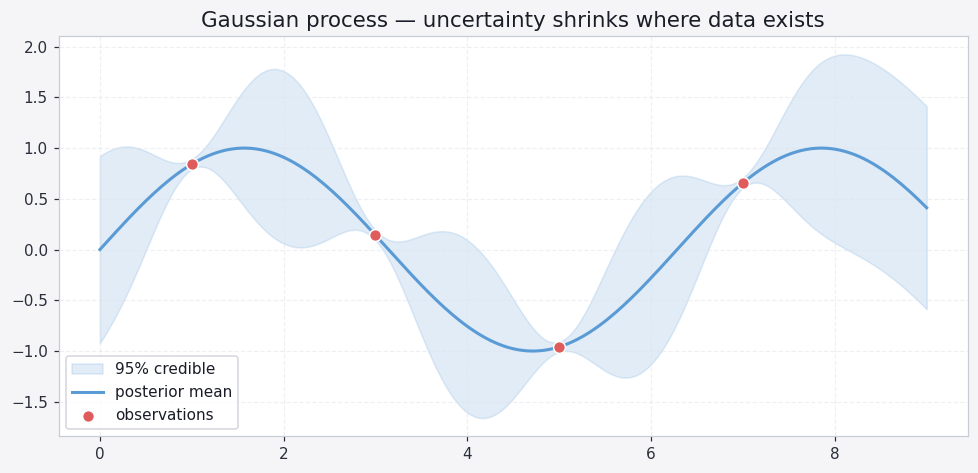

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
x_obs = np.array([1, 3, 5, 7]); y_obs = np.sin(x_obs)
x = np.linspace(0, 9, 200); mean = np.sin(x)
# Heuristic posterior std: small near observations, large between/outside.
std = 0.5*np.ones_like(x)
for xo in x_obs: std *= 1 - 0.95*np.exp(-((x-xo)**2)/0.4)
std = np.clip(std, 0.02, 0.6)
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.fill_between(x, mean-2*std, mean+2*std, color=P[0], alpha=0.18, label='95% credible')
ax.plot(x, mean, color=P[0], lw=2, label='posterior mean')
ax.scatter(x_obs, y_obs, s=60, color=P[1], edgecolor='white', zorder=5, label='observations')
ax.set_title('Gaussian process — uncertainty shrinks where data exists')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

def rbf(X1, X2, ell=1.0, sf=1.0):
    d2 = np.sum(X1**2, 1)[:, None] + np.sum(X2**2, 1)[None, :] - 2 * X1 @ X2.T
    return sf**2 * np.exp(-0.5 * d2 / ell**2)

rng = np.random.default_rng(0)
f = lambda x: np.sin(2*x) + 0.3*x
X_train = np.array([-2.5, -1.6, -0.4, 0.8, 1.7, 2.6])[:, None]
y_train = f(X_train.ravel()) + rng.normal(0, 0.15, len(X_train))
X_test = np.linspace(-3.5, 3.5, 200)[:, None]

---
## Kernel and Gram Matrix

An RBF / squared-exponential kernel:

$$k(x, x') = \sigma_f^2 \exp\!\bigl(- \tfrac{1}{2\ell^2}\|x - x'\|^2\bigr).$$

The **Gram matrix** $K_{ij} = k(x_i, x_j)$ encodes how strongly any two points are correlated *a priori*. The length scale $\ell$ sets the wiggle distance; $\sigma_f$ sets the function magnitude.

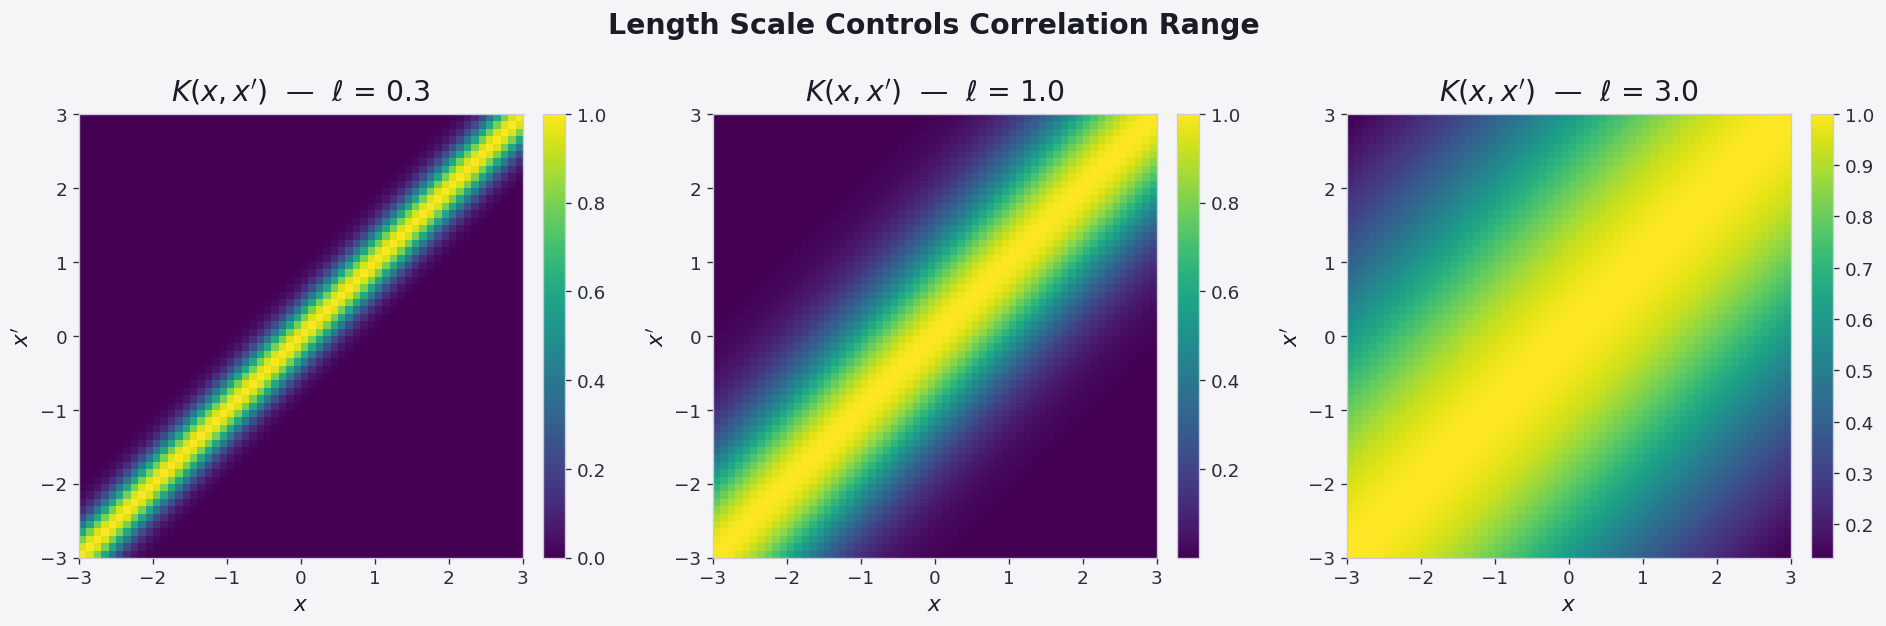

In [3]:
x_grid = np.linspace(-3, 3, 60)[:, None]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, ell in zip(axes, [0.3, 1.0, 3.0]):
    K = rbf(x_grid, x_grid, ell=ell)
    im = ax.imshow(K, cmap='viridis', extent=[-3, 3, -3, 3], origin='lower')
    ax.set_title(f'$K(x, x\')$  —  $\\ell$ = {ell}', pad=8)
    ax.set_xlabel('$x$'); ax.set_ylabel('$x\'$')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Length Scale Controls Correlation Range', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## Prior Samples

$\mathcal{GP}(0, k)$ is a distribution over functions. Drawing a sample reduces to drawing $\mathbf f \sim \mathcal{N}(\mathbf 0, K)$ at a finite grid of inputs.

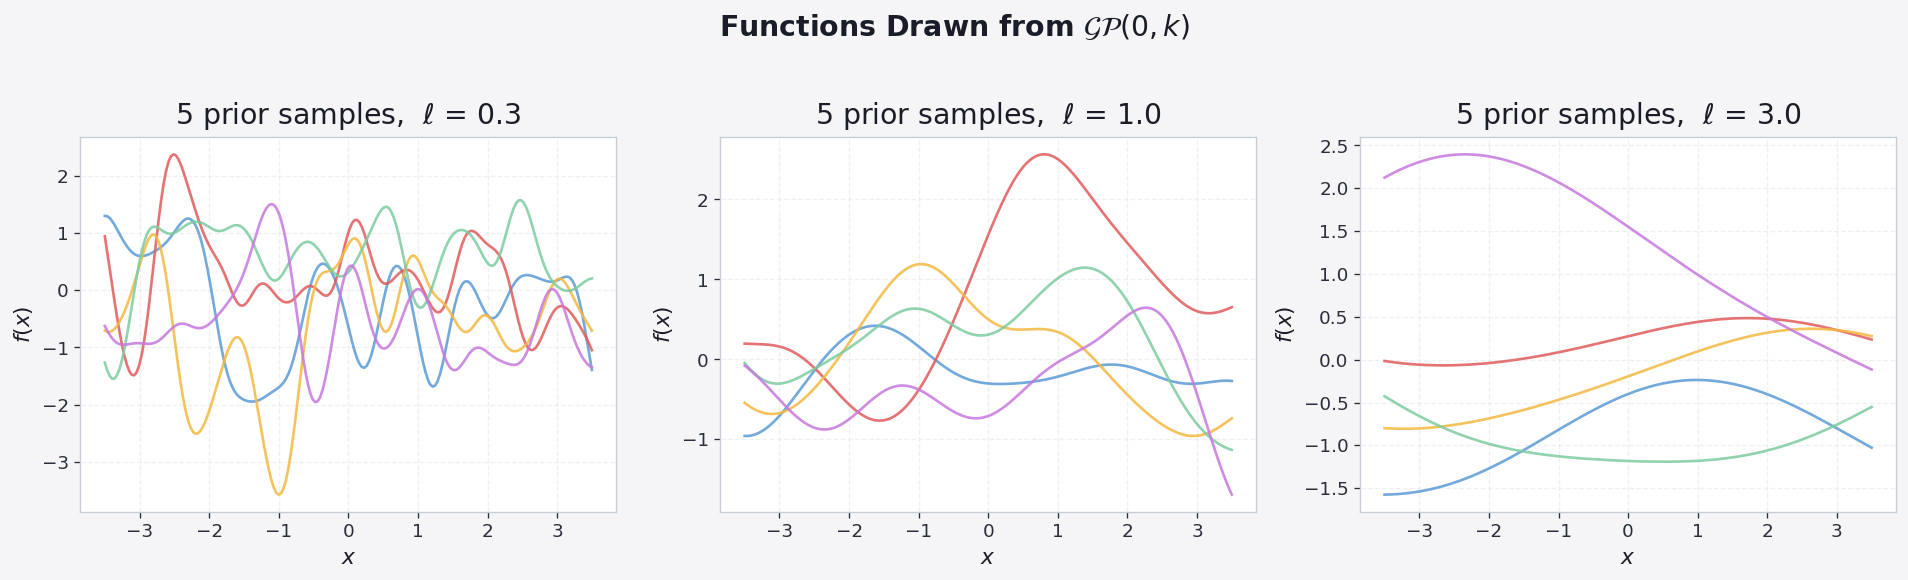

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, ell in zip(axes, [0.3, 1.0, 3.0]):
    K = rbf(X_test, X_test, ell=ell) + 1e-8 * np.eye(len(X_test))
    L = np.linalg.cholesky(K)
    samples = (L @ rng.standard_normal((len(X_test), 5))).T
    for s, c in zip(samples, [C0, C1, CB, CM, CP]):
        ax.plot(X_test.ravel(), s, color=c, lw=1.6, alpha=0.85)
    ax.set_title(f'5 prior samples,  $\\ell$ = {ell}', pad=8)
    ax.set_xlabel('$x$'); ax.set_ylabel('$f(x)$'); ax.grid(True)
fig.suptitle('Functions Drawn from $\\mathcal{GP}(0, k)$', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## Posterior — Conditioning on Data

Given training inputs $X$, targets $\mathbf y = f(X) + \varepsilon$, $\varepsilon \sim \mathcal N(0, \sigma_n^2 I)$, and test inputs $X^*$:

$$K_y = k(X, X) + \sigma_n^2 I, \quad K_*  = k(X, X^*), \quad K_{**} = k(X^*, X^*).$$

$$\boxed{\,\mu^* = K_*^T K_y^{-1} \mathbf y, \qquad \Sigma^* = K_{**} - K_*^T K_y^{-1} K_*.\,}$$

The posterior is itself Gaussian; standard deviations along the diagonal of $\Sigma^*$ give the 95 % band $\mu^* \pm 1.96 \sqrt{\operatorname{diag}(\Sigma^*)}$.

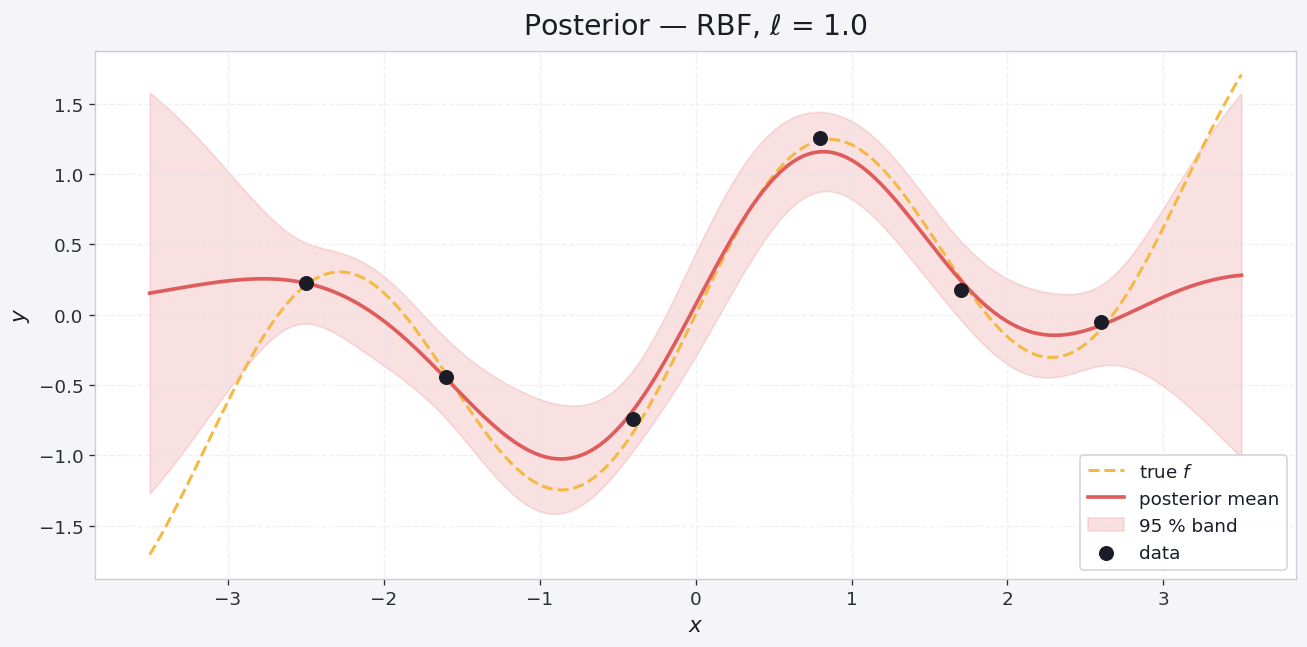

In [5]:
def gp_posterior(X, y, Xs, ell=1.0, sf=1.0, sn=0.15):
    Ky  = rbf(X, X, ell, sf) + sn**2 * np.eye(len(X))
    Ks  = rbf(X, Xs, ell, sf)
    Kss = rbf(Xs, Xs, ell, sf)
    L = np.linalg.cholesky(Ky)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    mu = Ks.T @ alpha
    v = np.linalg.solve(L, Ks)
    cov = Kss - v.T @ v
    return mu, np.sqrt(np.maximum(np.diag(cov), 0))

fig, ax = plt.subplots(figsize=(11, 5.5))
mu, sd = gp_posterior(X_train, y_train, X_test, ell=1.0, sn=0.15)
ax.plot(X_test, f(X_test.ravel()), color=CB, lw=1.8, ls='--', label='true $f$')
ax.plot(X_test, mu, color=C1, lw=2.2, label='posterior mean')
ax.fill_between(X_test.ravel(), mu - 1.96*sd, mu + 1.96*sd, color=C1, alpha=0.18, label='95 % band')
ax.scatter(X_train.ravel(), y_train, c='#1a1d27', s=70, zorder=5, edgecolors='#1a1d27', lw=0.6, label='data')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Posterior — RBF, $\\ell$ = 1.0', pad=10); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## Effect of Length Scale

Small $\ell$ → the posterior wiggles aggressively and uncertainty explodes between points. Large $\ell$ → the mean smooths everything but bias rises.

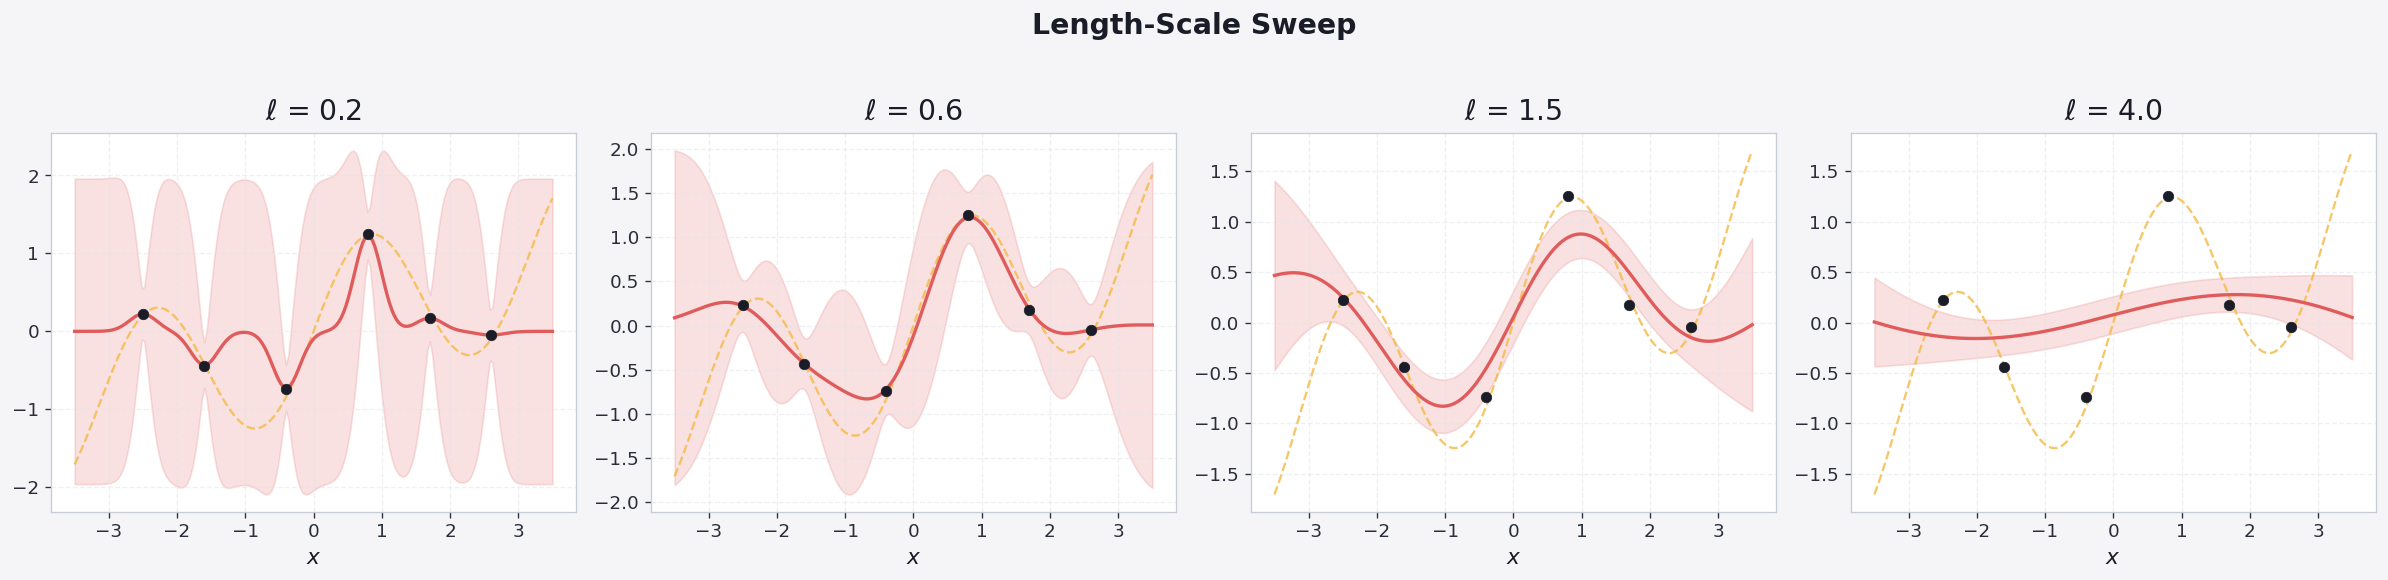

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
for ax, ell in zip(axes, [0.2, 0.6, 1.5, 4.0]):
    mu, sd = gp_posterior(X_train, y_train, X_test, ell=ell, sn=0.15)
    ax.plot(X_test, f(X_test.ravel()), color=CB, lw=1.4, ls='--', alpha=0.8)
    ax.plot(X_test, mu, color=C1, lw=2)
    ax.fill_between(X_test.ravel(), mu - 1.96*sd, mu + 1.96*sd, color=C1, alpha=0.18)
    ax.scatter(X_train.ravel(), y_train, c='#1a1d27', s=40, zorder=5, edgecolors='#1a1d27', lw=0.4)
    ax.set_title(f'$\\ell$ = {ell}', pad=8); ax.set_xlabel('$x$'); ax.grid(True)
fig.suptitle('Length-Scale Sweep', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## Effect of Noise $\sigma_n$

Larger $\sigma_n$ tells the GP to **distrust** the data. The posterior mean becomes smoother and never quite passes through the points; the band stays wider even at observed locations.

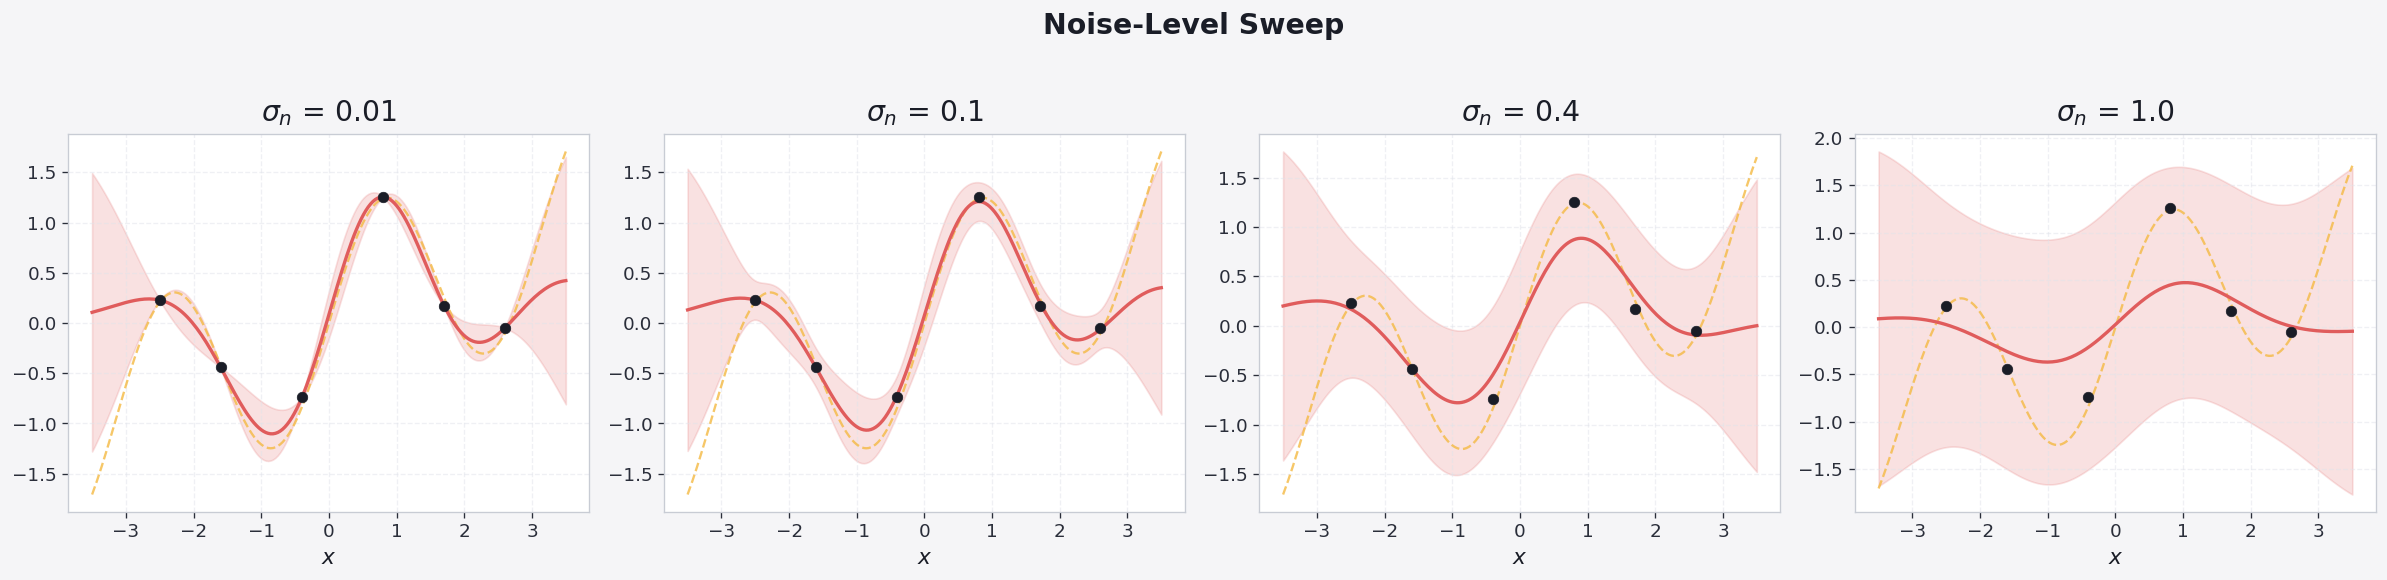

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
for ax, sn in zip(axes, [0.01, 0.1, 0.4, 1.0]):
    mu, sd = gp_posterior(X_train, y_train, X_test, ell=1.0, sn=sn)
    ax.plot(X_test, f(X_test.ravel()), color=CB, lw=1.4, ls='--', alpha=0.8)
    ax.plot(X_test, mu, color=C1, lw=2)
    ax.fill_between(X_test.ravel(), mu - 1.96*sd, mu + 1.96*sd, color=C1, alpha=0.18)
    ax.scatter(X_train.ravel(), y_train, c='#1a1d27', s=40, zorder=5, edgecolors='#1a1d27', lw=0.4)
    ax.set_title(f'$\\sigma_n$ = {sn}', pad=8); ax.set_xlabel('$x$'); ax.grid(True)
fig.suptitle('Noise-Level Sweep', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use a GP — and when not to

| Situation | GP | LWR | Spline | Random Forest |
|---|---|---|---|---|
| Need calibrated uncertainty | ✅ closed-form posterior | ❌ | ❌ | partial (quantile) |
| Small / medium dataset ($n < 5\,000$) | ✅ | ✅ | ✅ | ✅ |
| Big data ($n > 10\,000$) | ❌ $O(n^3)$ | ❌ | ✅ | ✅ |
| Choose meaningful prior | ✅ kernel encodes beliefs | partial | ❌ | ❌ |

> Use a GP for **Bayesian optimisation, active learning, or any task where the *predictive variance* matters as much as the mean**.


---
## 🎯 Try this

1. **Kernel surgery.** Swap RBF for Matern-$3/2$ and Periodic. Refit on the same data and compare the posterior mean and 95% band — Matern is rougher; Periodic forces repetition.
2. **Likelihood maximisation.** Hand-grid the kernel length-scale $\ell$ and signal variance $\sigma_f^2$, plot the marginal log-likelihood, and confirm sklearn's optimiser finds the same peak.
3. **Sparse GP intuition.** Down-sample to $m=20$ inducing points and refit — the band should widen between inducing points but the trend should match.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Kernel $k$ | Encodes prior smoothness/correlation | Choice = inductive bias |
| Length scale $\ell$ | Range over which $f$ is correlated | Tunes wiggle / smoothness |
| Signal scale $\sigma_f$ | Function magnitude | Vertical stretch |
| Noise $\sigma_n$ | How much to distrust observations | Adds to diagonal of $K_y$ |
| Posterior mean | $K_*^T K_y^{-1} \mathbf y$ | Best predictor |
| Posterior cov | $K_{**} - K_*^T K_y^{-1} K_*$ | Calibrated uncertainty for free |
| Strength | Principled uncertainty, few hyper-params | Bayesian optimisation, small-data regression |
| Weakness | $O(N^3)$ training, $O(N^2)$ memory | Sparse / inducing-point GPs scale to $N \sim 10^5$ |

**Bottom line:** A GP gives you a predictor **with calibrated error bars**. Choose a kernel, fit the length / noise scales (often by maximising marginal likelihood), and the posterior tells you both the best estimate and how much it knows.